# TS5: Estimación espectral: Ancho de banda de señales reales

## Alumno: Felipe Berganza 

# Resumen 

Este informe técnico presenta el análisis espectral y cálculo del Ancho de Banda ocupado (BW) para señales biomédicas (ECG y PPG) y de audio, evaluando el impacto del ruido sobre sus componentes frecuenciales. Se estimó la Densidad Espectral de Potencia (PSD) mediante el Método de Welch (con ventanas Hamming/Hanning y zero-padding para mejorar la resolución visual), y se determinaron las frecuencias de corte inferior ($F_{inf}$) y superior ($F_{sup}$) mediante la acumulación de energía (np.cumsum) bajo el criterio del 99% central de la potencia. Los resultados se consolidaron en gráficos de subplots emparejados que contrastan de forma directa el comportamiento de cada señal en el dominio del tiempo frente a su distribución energética en el dominio de la frecuencia.

# INTRODUCCION

## Densidad Espectral de Potencia (PSD)

La Densidad Espectral de Potencia (PSD, por sus siglas en inglés, Power Spectral Density) es una herramienta fundamental del procesamiento digital de señales que describe cómo se distribuye la potencia de una señal a lo largo del dominio de la frecuencia. A diferencia de la Transformada de Fourier tradicional (FFT), que entrega información de magnitud y fase para señales determinísticas, la PSD es una medida estadística indispensable para analizar señales estocásticas, procesos aleatorios o señales complejas de la vida real (como registros biomédicos de ECG/PPG o señales de audio).

Para estimar la PSD existen diversos enfoques. El periodograma directo (basado en el cuadrado de la FFT) suele sufrir de una varianza muy alta que introduce un "falso ruido" en el espectro. Por este motivo, en este trabajo se optó por el Método de Welch: un estimador no paramétrico que divide la señal en bloques superpuestos, les aplica una función de ventana (Hamming/Hanning) para reducir el esparcimiento espectral (spectral leakage), y promedia los periodogramas resultantes. Este compromiso reduce la varianza de la estimación a cambio de una leve pérdida en la resolución frecuencial, entregando un perfil espectral suave y físicamente representativo del fenómeno analizado.

## Metodos Espectrales 

1. Limitación del Periodograma Clásico: Calcular la PSD directamente como el módulo al cuadrado de la FFT de toda la señal posee una desventaja crítica: es un estimador inconsistente. A medida que aumenta el número de muestras ($N$), la varianza del periodograma no disminuye, sino que el espectro se vuelve altamente errático y lleno de fluctuaciones filosas que enmascaran la verdadera distribución de potencia.

2. El Método de Welch: Para solucionar este problema de varianza, se utiliza el método de Welch (o periodograma promediado modificado). El algoritmo divide la señal en $M$ bloques de datos que se solapan entre sí (típicamente al 50%). A cada bloque se le aplica una función de ventana (Hamming para las señales biomédicas y Hanning para las de audio) con el fin de atenuar los bordes y reducir el spectral leakage (esparcimiento espectral provocado por el truncamiento de la señal). Finalmente, se calcula el periodograma de cada bloque y se promedian los resultados. Este promedio reduce drásticamente la varianza del estimador por un factor de aproximadamente $1/M$, entregando una curva espectral suave y físicamente interpretable a cambio de una reducción controlada en la resolución frecuencial.

3. Zero-Padding (Relleno de Ceros): En combinación con el método de Welch, se aplica zero-padding al configurar el parámetro nfft a diez veces el largo del segmento original (10 * nperseg). Al agregar ceros al final de cada bloque antes de calcular la FFT, se realiza una interpolación ideal en el dominio de la frecuencia. Es importante destacar que el zero-padding no mejora la resolución espectral real (la capacidad de distinguir dos tonos muy cercanos, la cual sigue limitada por el largo del bloque), pero sí incrementa la densidad de puntos calculados, suavizando la visualización de la PSD y permitiendo una localización mucho más precisa de las frecuencias de corte para el cálculo del Ancho de Banda.

# DESARROLLO

--- Resultados ECG sin Ruido ---
Frecuencia inferior (0.5%): 0.32 Hz
Frecuencia superior (99.5%): 36.12 Hz
Ancho de Banda (99%): 35.80 Hz


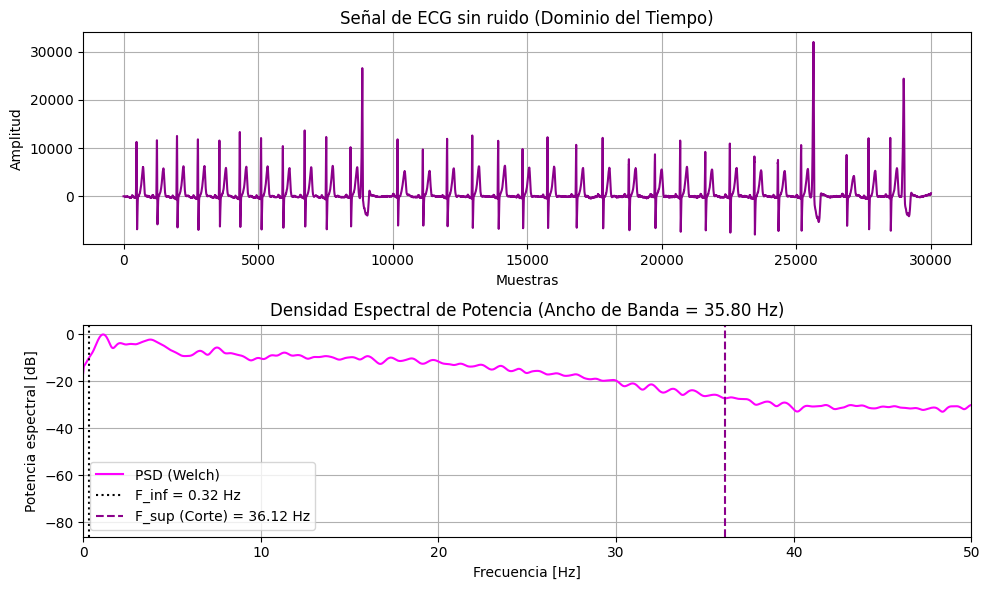

In [2]:
#%%
import numpy as np
import scipy.io as sio
import scipy.signal as sig
import matplotlib.pyplot as plt
#%%
# =============================================================================
# 1. CARGA DE SEÑAL BIOMÉDICA (ECG SIN RUIDO)
# =============================================================================
# Cargo el diccionario completo desde el archivo .mat
ECG_contenido = sio.loadmat('ECG_TP4.mat')

# Señal de ECG cruda (una sola derivación)
ecg_one_lead = ECG_contenido['ecg_lead'] 

# Cargar la versión de la señal de ECG ya procesada (sin ruido)
ECG_sr = np.load('ecg_sin_ruido.npy')

# Defino Parametros 
fs_ECG = 1000                  # Frecuencia de muestreo (Hz)
N_ECG_sr = len(ECG_sr)         # Largo de la señal
df_ECG_sr = fs_ECG / N_ECG_sr  # Resolucion Espectral teórica (FFT completa)
nn_ECG_sr = np.arange(N_ECG_sr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (ECG SIN RUIDO)
# =============================================================================
promedios_ECG_sr = 12 
nperseg_ECG_sr = N_ECG_sr // promedios_ECG_sr 
nfft_ecg_pad = nperseg_ECG_sr * 10 # Zero-padding aplicado al ECG
ff_ECG_sr, per_ECG_sr = sig.welch(ECG_sr, fs=fs_ECG, window='hamming', scaling='density', nperseg=nperseg_ECG_sr, nfft=nfft_ecg_pad) 

per_ECG_sr_norm = per_ECG_sr / np.max(np.abs(per_ECG_sr)) # Normalizo la señal

per_ECG_sr_db = 10 * np.log10(per_ECG_sr_norm) # La convierto a dB 

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_sr = np.cumsum(per_ECG_sr) 
energia_acum_sr_norm = energia_acum_sr / energia_acum_sr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_sr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_sr_norm >= 0.995)[0][0])

frec_inf_sr = ff_ECG_sr[idx_inf]
frec_corte_sr = ff_ECG_sr[idx_sup]
ancho_banda_ecg = frec_corte_sr - frec_inf_sr

print(f"--- Resultados ECG sin Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_sr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_sr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ecg:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL ECG Y SU PSD
# =============================================================================
plt.figure(2, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_ECG_sr, ECG_sr, color='darkmagenta')
plt.title("Señal de ECG sin ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_ECG_sr, per_ECG_sr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_sr, linestyle=':', color='black', label=f'F_inf = {frec_inf_sr:.2f} Hz')
plt.axvline(frec_corte_sr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_sr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ecg:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(0, 50) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()

# Interpretacion 

El análisis espectral de la señal de ECG sin ruido revela un ancho de banda del $99\%$ central de $35.80\text{ Hz}$, delimitado con precisión entre $F_{inf} = 0.32\text{ Hz}$ y $F_{sup} = 36.12\text{ Hz}$. La concentración de energía por debajo de los $40\text{ Hz}$ es sumamente coherente con la fisiología cardíaca (morfología del complejo QRS), mientras que el corte inferior en $0.32\text{ Hz}$ tambien lo es. Asimismo, el decaimiento sostenido de la PSD por debajo de los $-30\text{ dB}$ confirma la ausencia de interferencias de alta frecuencia o picos espurios de línea ($50\text{ Hz}$). Metodológicamente, el Método de Welch con ventana Hamming redujo eficientemente la varianza del estimador, y la combinación con zero-padding aportó una interpolación ideal que optimizó la localización algorítmica de los límites energéticos.

--- Resultados ECG con Ruido ---
Frecuencia inferior (0.5%): 0.05 Hz
Frecuencia superior (99.5%): 51.75 Hz
Ancho de Banda (99%): 51.70 Hz


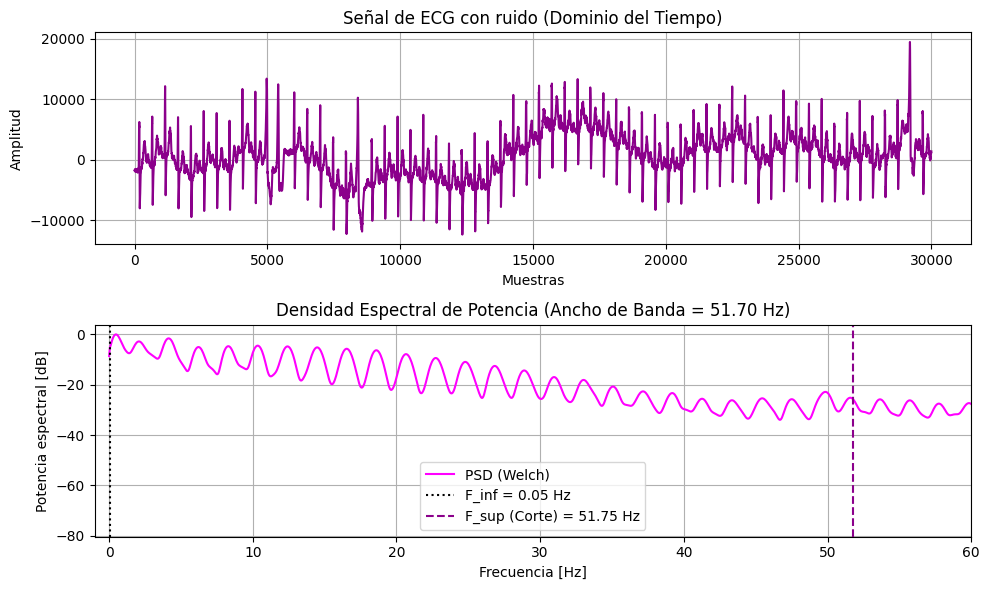

In [3]:
# =============================================================================
# 1. CARGA DE SEÑAL BIOMÉDICA (ECG CON RUIDO)
# =============================================================================

# Cargar la versión de la señal de ECG ya procesada (con ruido)
ECG_cr = ecg_one_lead[670000:700000].ravel()

# Defino Parametros 
fs_ECG = 1000                  # Frecuencia de muestreo (Hz)
N_ECG_cr = len (ECG_cr)       # Largo de la señal
df_ECG_cr = fs_ECG / N_ECG_cr  # Resolucion Espectral teórica (FFT completa)
nn_ECG_cr = np.arange (N_ECG_cr) # Vector de muestras 

# =============================================================================
# 2. ESTIMACIÓN ESPECTRAL VÍA MÉTODO WELCH (ECG CON RUIDO)
# =============================================================================
promedios_ECG_cr = 15 
nperseg_ECG_cr = N_ECG_cr // promedios_ECG_cr 
nfft_ecg_pad = nperseg_ECG_cr * 10 # Zero-padding aplicado al ECG
ff_ECG_cr, per_ECG_cr = sig.welch(ECG_cr, fs=fs_ECG, window='hamming', scaling='density', nperseg=nperseg_ECG_cr, nfft=nfft_ecg_pad) 

per_ECG_cr_norm = per_ECG_cr / np.max(np.abs(per_ECG_cr)) # Normalizo la señal

per_ECG_cr_db = 10 * np.log10(per_ECG_cr_norm) # La convierto a dB 

# =============================================================================
# 3. CÁLCULO DE ANCHO DE BANDA (BW) POR ACUMULACIÓN DE POTENCIA (99% Central)
# =============================================================================
energia_acum_cr = np.cumsum(per_ECG_cr) 
energia_acum_cr_norm = energia_acum_cr / energia_acum_cr[-1] 

# Buscamos los índices que encierran el 99% central de la potencia
idx_inf = int(np.where(energia_acum_cr_norm >= 0.005)[0][0])
idx_sup = int(np.where(energia_acum_cr_norm >= 0.995)[0][0])

frec_inf_cr = ff_ECG_cr[idx_inf]
frec_corte_cr = ff_ECG_cr[idx_sup]
ancho_banda_ecg_cr = frec_corte_cr - frec_inf_cr

print(f"--- Resultados ECG con Ruido ---")
print(f"Frecuencia inferior (0.5%): {frec_inf_cr:.2f} Hz")
print(f"Frecuencia superior (99.5%): {frec_corte_cr:.2f} Hz")
print(f"Ancho de Banda (99%): {ancho_banda_ecg_cr:.2f} Hz")

# =============================================================================
# 4. PLOT DE SEÑAL ECG Y SU PSD
# =============================================================================
plt.figure(3, figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(nn_ECG_cr, ECG_cr, color='darkmagenta')
plt.title("Señal de ECG con ruido (Dominio del Tiempo)")
plt.ylabel("Amplitud")
plt.xlabel("Muestras")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(ff_ECG_cr, per_ECG_cr_db, color='magenta', label='PSD (Welch)')
plt.axvline(frec_inf_cr, linestyle=':', color='black', label=f'F_inf = {frec_inf_cr:.2f} Hz')
plt.axvline(frec_corte_cr, linestyle='--', color='darkmagenta', label=f'F_sup (Corte) = {frec_corte_cr:.2f} Hz')
plt.title(f"Densidad Espectral de Potencia (Ancho de Banda = {ancho_banda_ecg_cr:.2f} Hz)")
plt.ylabel("Potencia espectral [dB]")
plt.xlabel("Frecuencia [Hz]")
plt.grid(True)
plt.legend()
plt.xlim(-1, 60) # Acotamos la vista a la zona de interés del ECG

plt.tight_layout()
plt.show()